## NTSC to RF simulation

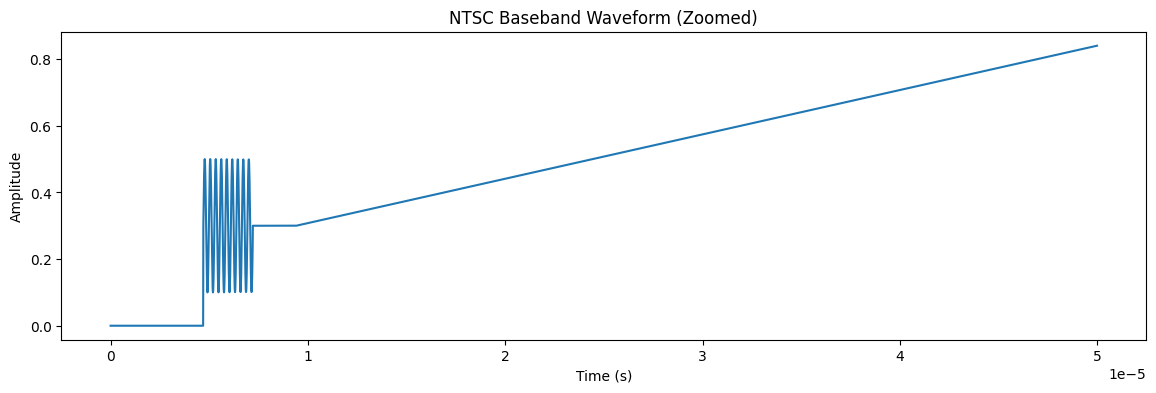

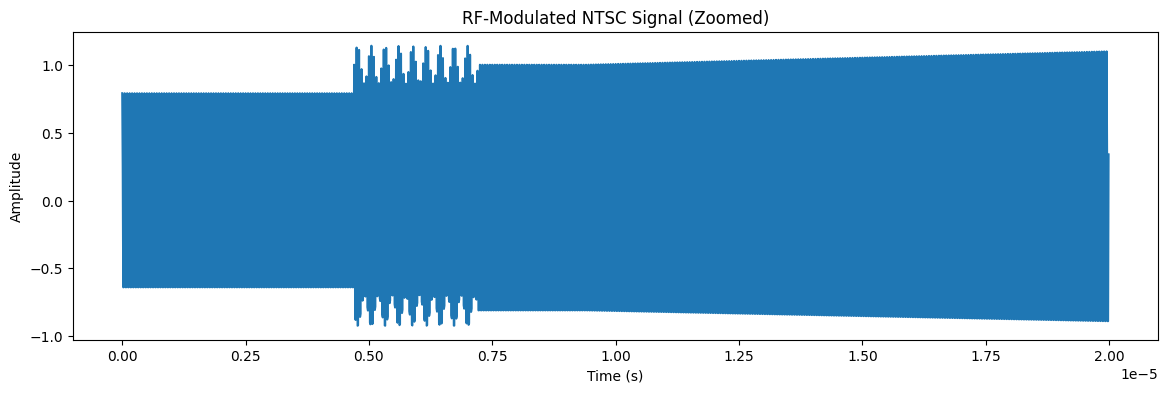

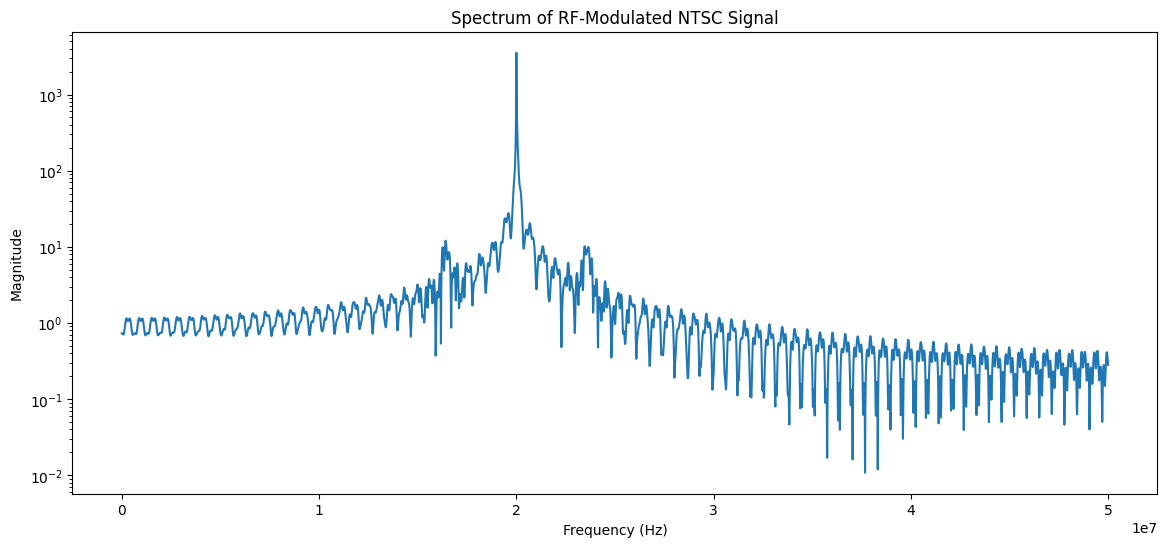

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------
# PARAMETERS
# ---------------------------------------------
Fs = 100e6                        # Sampling rate
line_duration = 1/15734           # Horizontal line ~63.556 µs
t = np.arange(0, line_duration, 1/Fs)

# NTSC timing constants
sync_dur = 4.7e-6
back_porch_dur = 4.7e-6
active_dur = 52.6e-6
front_porch_dur = line_duration - (sync_dur + back_porch_dur + active_dur)

# Colorburst
burst_freq = 3.579545e6
burst_cycles = 9
burst_amp = 0.2

# ---------------------------------------------
# GENERATE NTSC BASEBAND LINE
# ---------------------------------------------
ntsc = np.ones_like(t) * 0.3      # blanking level ~0.3 V

# Sync tip
sync_end = int(sync_dur * Fs)
ntsc[:sync_end] = 0.0

# Back porch + burst
bp_end = sync_end + int(back_porch_dur * Fs)
burst_len = int(burst_cycles / burst_freq * Fs)

n = np.arange(burst_len)
burst = burst_amp * np.sin(2*np.pi*burst_freq*n/Fs)

ntsc[sync_end:sync_end + burst_len] += burst

# Active video (just a gradient ramp)
active_start = bp_end
active_end = active_start + int(active_dur * Fs)
gradient = np.linspace(0.3, 1.0, active_end - active_start)

ntsc[active_start:active_end] = gradient

# ---------------------------------------------
# RF MODULATION (AM-VSB-like)
# ---------------------------------------------
Fc = 20e6        # RF carrier (for real NTSC this is 55–801 MHz, but 20 MHz is easy to plot)
mod_depth = 0.7

carrier = np.cos(2*np.pi*Fc*t)
rf = (1 + mod_depth * (ntsc - 0.3)) * carrier  # AM modulation

# ---------------------------------------------
# TIME DOMAIN PLOTS
# ---------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(t[:5000], ntsc[:5000])
plt.title("NTSC Baseband Waveform (Zoomed)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(t[:2000], rf[:2000])
plt.title("RF-Modulated NTSC Signal (Zoomed)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# ---------------------------------------------
# FREQUENCY DOMAIN (FFT)
# ---------------------------------------------
N = len(rf)
freq = np.fft.fftfreq(N, 1/Fs)
spectrum = np.abs(np.fft.fft(rf))

plt.figure(figsize=(14,6))
plt.semilogy(freq[:N//2], spectrum[:N//2])
plt.title("Spectrum of RF-Modulated NTSC Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()


## Parser

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [48]:
FOLDER = "./scans/rec2"
START_IDX = 0
END_IDX = 67

In [49]:
def load_s2p(filepath):
    """Read a TinySA Ultra .s2p file with comma decimals."""
    data = []
    with open(filepath, "r") as f:
        for line in f:
            if line.startswith("!"):   # skip header
                continue
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            # Replace comma decimal with dot
            freq = float(parts[0].replace(",", "."))
            S11_real = float(parts[1].replace(",", "."))
            S11_imag = float(parts[2].replace(",", "."))
            S21_real = float(parts[3].replace(",", "."))
            S21_imag = float(parts[4].replace(",", "."))

            data.append([freq, S11_real, S11_imag, S21_real, S21_imag])

    df = pd.DataFrame(data, columns=["freq", "S11r", "S11i", "S21r", "S21i"])
    return df

In [50]:
sweeps = []
for i in range(START_IDX, END_IDX + 1):
    path = os.path.join(FOLDER, f"{i}.s2p")
    sweeps.append(load_s2p(path))

print(f"Loaded {len(sweeps)} sweeps.")
print(sweeps)

Loaded 68 sweeps.
[             freq      S11r  S11i  S21r  S21i
0    2.190000e+09  0.000016   0.0   0.0   0.0
1    2.193774e+09  0.000019   0.0   0.0   0.0
2    2.197548e+09  0.000017   0.0   0.0   0.0
3    2.201321e+09  0.000020   0.0   0.0   0.0
4    2.205095e+09  0.000011   0.0   0.0   0.0
..            ...       ...   ...   ...   ...
995  5.944905e+09  0.001353   0.0   0.0   0.0
996  5.948679e+09  0.000453   0.0   0.0   0.0
997  5.952452e+09  0.000510   0.0   0.0   0.0
998  5.956226e+09  0.001286   0.0   0.0   0.0
999  5.960000e+09  0.000431   0.0   0.0   0.0

[1000 rows x 5 columns],              freq      S11r  S11i  S21r  S21i
0    2.190000e+09  0.000013   0.0   0.0   0.0
1    2.193774e+09  0.000016   0.0   0.0   0.0
2    2.197548e+09  0.000011   0.0   0.0   0.0
3    2.201321e+09  0.000034   0.0   0.0   0.0
4    2.205095e+09  0.000009   0.0   0.0   0.0
..            ...       ...   ...   ...   ...
995  5.944905e+09  0.001210   0.0   0.0   0.0
996  5.948679e+09  0.000383   0.0  

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

# Use S11 magnitude
magnitudes = [np.abs(df["S11r"]) for df in sweeps]
freq = sweeps[0]["freq"].values

# Precompute global y-limits
ymax = max(m.max() for m in magnitudes)
ymax = ymax * 1.2 if ymax > 0 else 1e-6

fig, ax = plt.subplots(figsize=(10,5))
(line,) = ax.plot([], [], lw=1.2)

ax.set_xlim(freq.min(), freq.max())
ax.set_ylim(0, ymax)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("S11 magnitude")
ax.set_title("TinySA Ultra sweep animation")

def update(frame):
    line.set_data(freq, magnitudes[frame])
    ax.set_title(f"Sweep #{frame}")
    return (line,)

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

ani = FuncAnimation(
    fig, update,
    frames=len(sweeps),
    interval=100,
    blit=False
)

HTML(ani.to_jshtml())


<IPython.core.display.Javascript object>

## Classifier

In [54]:
import numpy as np

# ----------------------------------------
# Peak detection helper
# ----------------------------------------
def find_local_peak(freq, power, target_freq, window=0.5e6):
    """Finds a peak near target_freq within ±window."""
    idx = np.where((freq >= target_freq - window) & (freq <= target_freq + window))[0]
    if len(idx) == 0:
        return None, None
    local_idx = idx[np.argmax(power[idx])]
    return freq[local_idx], power[local_idx]


# ----------------------------------------
# Detection of NTSC features
# ----------------------------------------
def detect_ntsc_features(freq, power):
    """Returns dict with detected NTSC features or None."""
    
    # 1. Main carrier (strongest peak)
    carrier_idx = np.argmax(power)
    carrier_freq = freq[carrier_idx]
    carrier_amp  = power[carrier_idx]

    # Noise floor approximation
    noise_floor = np.median(power)

    # Reject very weak signals
    if carrier_amp < noise_floor + 5:   # 5 dB above noise
        return None

    # Expected offsets
    CHROMA_OFF = 3.579545e6
    AUDIO_OFF  = 4.5e6

    # 2. Find chroma subcarrier
    chroma_freq_expected = carrier_freq + CHROMA_OFF
    chroma_freq, chroma_amp = find_local_peak(freq, power, chroma_freq_expected)

    if chroma_freq is None or chroma_amp < noise_floor + 2:
        return None  # must exist

    chroma_offset = chroma_freq - carrier_freq

    # 3. Find audio subcarrier
    audio_freq_expected = carrier_freq + AUDIO_OFF
    audio_freq, audio_amp = find_local_peak(freq, power, audio_freq_expected)

    if audio_freq is None or audio_amp < noise_floor + 2:
        return None

    audio_offset = audio_freq - carrier_freq

    # 4. Sideband asymmetry (Vestigial Sideband check)
    left = power[(freq > carrier_freq - 2e6) & (freq < carrier_freq)]
    right = power[(freq > carrier_freq) & (freq < carrier_freq + 2e6)]

    if len(left) == 0 or len(right) == 0:
        return None

    if np.mean(right) < np.mean(left):   # NTSC upper SB must be stronger
        return None

    # All checks passed → NTSC detected
    return {
        "carrier_freq": carrier_freq,
        "carrier_amp": carrier_amp,
        "chroma_freq": chroma_freq,
        "chroma_offset": chroma_offset,
        "audio_freq": audio_freq,
        "audio_offset": audio_offset,
    }


# ----------------------------------------
# Wrapper for sweep processing
# ----------------------------------------
def process_sweep(freq, power, sweep_index):
    result = detect_ntsc_features(freq, power)

    print(f"\nSweep {sweep_index}:")

    if result is None:
        print("  No NTSC-like signal detected")
        return False

    print(f"  NTSC carrier detected at {result['carrier_freq'] / 1e9:.6f} GHz")
    print(f"  Chroma subcarrier at +{result['chroma_offset'] / 1e6:.3f} MHz ✔")
    print(f"  Audio subcarrier  at +{result['audio_offset'] / 1e6:.3f} MHz ✔")
    print(f"  → NTSC signal detected\n")

    return True


In [55]:
for sweep_id, sweep in enumerate(sweeps):
    freq = sweep["freq"]
    power = sweep["power"]
    process_sweep(freq, power, sweep_id)


KeyError: 'power'